# Objective 1

The first of the three objectives of this Bachelor's Thesis is to perform a fit of Parton Distribution Function (PDF) as given by LHAPDF. This first objective will focus on building a neural network to fit the PDFs using Machine Learning techniques to observe the dynamic behavior of protons. This is quite useful as it helps to understand the initial state of partons inside the proton before a collision.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from collections import defaultdict
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from utils.functions import pid_to_latex

tf.keras.backend.clear_session()

### Load the data ###
# The data is stored in a .npy file, which contains the following arrays:
# - pdf_target: the target probability density function (PDF) values for each sample
# - x_q2_inputs: the input values for the variable x and Q^2 for each sample
# - pids_info: the particle IDs (PIDs) for each sample
data_path = "data/"

try:
    x_q2_inputs = np.load(os.path.join(data_path, "x_q2_inputs.npy"))
    val_pdf = np.load(os.path.join(data_path, "pdf_targets.npy"))
    pids = list(np.load(os.path.join(data_path, "pids_info.npy")))

    print("Data successfully loaded. Data of NNPDF40_nnlo_as_01180 set is being used.")
    print(f"Inputs Format (X): {x_q2_inputs.shape}  -> [points, (x, Q2)]")
    print(f"Targets Format (y): {val_pdf.shape} -> [values, flavors]")
    print(f"PIDs included: {pids}")

except FileNotFoundError:
    print(
        "Error: Data files not found. Please ensure the .npy files are in the 'data/' directory."
    )
    exit(1)

input_xgrid = x_q2_inputs[:, 0]
input_q2grid = x_q2_inputs[:, 1]

# Check the unique Q^2 values to understand the range of energy scales in the dataset
unique_q2 = np.unique(input_q2grid)
print(f"Dataset cargado con {len(unique_q2)} escalas de energía.")
print(f"Rango de x: [{input_xgrid.min():.2e}, {input_xgrid.max():.2f}]")

Data successfully loaded. Data of NNPDF40_nnlo_as_01180 set is being used.
Inputs Format (X): (100000000, 2)  -> [points, (x, Q2)]
Targets Format (y): (100000000, 11) -> [values, flavors]
PIDs included: [21, 1, 2, 3, 4, 5, -1, -2, -3, -4, -5]
Dataset cargado con 1000 escalas de energía.
Rango de x: [1.00e-05, 1.00]


## Visualization of experimental data.

Before we start creating our NN model, we will plot experimental data from some PDFs so we can examine them. To see how the necessary dataset was generated, see data/generate_dataset.py.

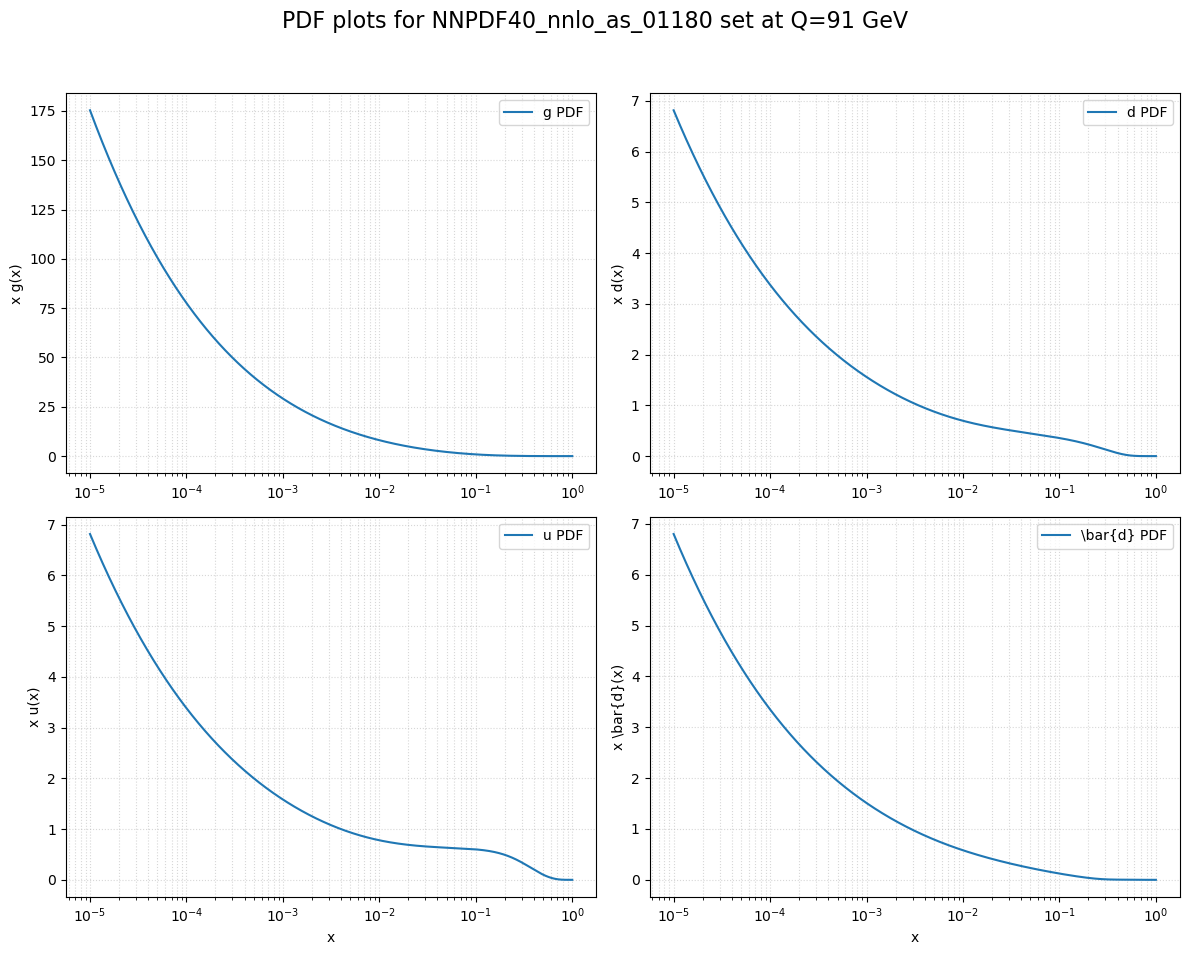

In [2]:
# Configure the scales energies for plotting
scales = [
    91
]  # Plot at the Z boson mass scale, Q = 91 GeV. We can also add more scales if desired.
# Some flavours to plot
flavour_select = [21, 1, 2, -1]  # gluon, down, up, anti-down

# Search the close Q^2 values to the desired scales for plotting
for i, q_gev in enumerate(scales):
    target_q2 = q_gev**2
q2_val = unique_q2[np.argmin(np.abs(unique_q2 - target_q2))]

mask = input_q2grid == q2_val
x_plot = input_xgrid[mask]
pdf_plot = val_pdf[mask]
pdf_grid = defaultdict(list)

for point in pdf_plot:
    for pid in flavour_select:
        pdf_grid[pid_to_latex(pid)].append(point[pids.index(pid)])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"PDF plots for NNPDF40_nnlo_as_01180 set at Q={q_gev} GeV", fontsize=16)

for i, (parton, val) in enumerate(pdf_grid.items()):
    ax = axes.flatten()[i]

    ax.plot(x_plot, val, label=rf"{parton} PDF")
    ax.set_xscale("log")
    ax.set_ylabel(rf"x {parton}(x)")
    if i >= 2:
        ax.set_xlabel("x")
    ax.legend()
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


We can observe that the input data involves different scales and wich require some form of preprocessing of the input.

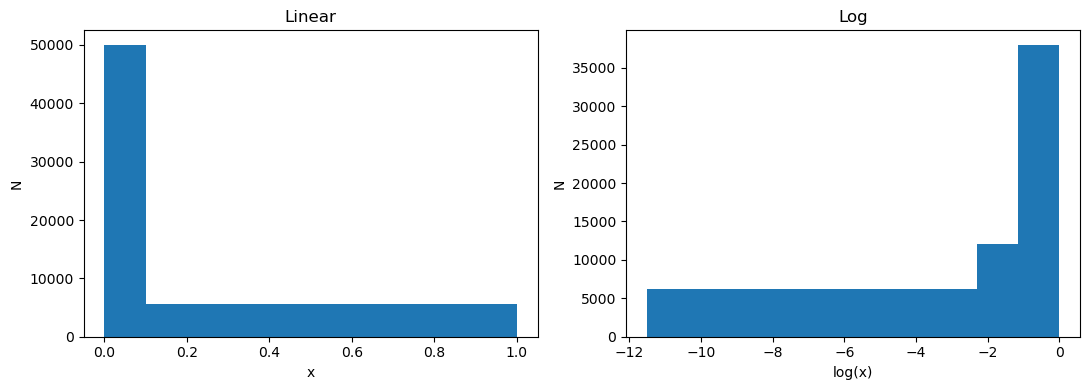

In [3]:
c, b = np.histogram(x_plot)
cl, bl = np.histogram(np.log(x_plot))

plt.subplots(1, 2, figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.title("Linear")
plt.stairs(c, b, fill=True)
plt.xlabel("x")
plt.ylabel("N")
plt.subplot(1, 2, 2)
plt.title("Log")
plt.stairs(cl, bl, fill=True)
plt.xlabel("log(x)")
plt.ylabel("N")

plt.tight_layout()
plt.show()

## NN - PDF

To train our model, we would need to use the dataset generated by our PDF. The problem is that the dataset has a total of $10⁵ \cdot 10³ = 10⁸$ points, making it quite large. To train the model, we used data filtering, selecting more points close to values ​​of $x$ and fewer points for values ​​farther from $x$.

In [4]:
### Create a mask to filter the dataset based on the specified conditions for x and PDF values ###
probabilities = np.random.rand(
    len(x_q2_inputs)
)  # Generate random probabilities for each sample
mask = (
    ((input_xgrid < 1e-3) & (probabilities < 0.50))
    | ((input_xgrid >= 1e-3) & (input_xgrid < 0.1) & (probabilities < 0.10))
    | ((input_xgrid >= 0.1) & (probabilities < 0.01))
)

inputs = x_q2_inputs[mask]
x_inputs = inputs[:, 0]
q2_inputs = inputs[:, 1]
val = val_pdf[mask]
pid_cols = {pid: i for i, pid in enumerate(pids)}


Prepare the output data for training the model. We will focus on the following quark flavours:$g, u, d, s, c, \bar{u}, \bar{d}, \bar{s}, \bar{c}$.

In [5]:
output_basis = [
    -4,
    -3,
    -2,
    -1,
    21,
    1,
    2,
    3,
    4,
]
noutput = len(output_basis)  # Number of flavors (columns in val)

output_data = np.zeros((len(val), noutput))
print(f"Number of samples: {len(val)}, Number of flavors: {noutput}")

pdf_grid = defaultdict(list)

for j, pid in enumerate(output_basis):
    col_idx = pid_cols[pid]
    output_data[:, j] = val[:, col_idx]

output_data = np.array(output_data)

# Normalize each column by its maximum value
max_vals = np.max(output_data, axis=0)
output_data_norm = output_data / max_vals

Number of samples: 15501029, Number of flavors: 9


To create our model with TensorFlow, we will build custom layers with physical meaning. One of them will use a logarithmic scale to approximate the behavior at very small $x$ scales. We will also add another custom layer to our network to ensure that the limit as $x$ approaches 1 is $x = 0$ using the factor: $(1-x)^{\beta+1}$
- **InputScaling**: Introduce $\log(x)$ y $\log(Q²)$.
- **Preprocessing**: Ensure the limit $x \to 1$.

In [6]:
## Layers ##
class InputScaling(tf.keras.layers.Layer):
    """ "Logarithmic scaling of the input data."""

    def call(self, inputs):
        # inputs[:,0] it's x and inputs[:,1] it's Q2
        x = inputs[:, 0:1]
        q2 = inputs[:, 1:2]

        log_x = tf.math.log(x + 1e-10)  # Add a small constant to avoid log(0)
        log_q2 = tf.math.log(q2 + 1e-10)  # Add a small constant to avoid log(0)

        return tf.concat([x, log_x, log_q2], axis=-1)


class Preprocessing(tf.keras.layers.Layer):
    def __init__(self, noutput, **kwargs):
        super().__init__(**kwargs)
        self.noutput = noutput

    def build(self, input_shape):
        # Beta is now a vector of length noutput, one for each output flavor
        self._beta = self.add_weight(
            shape=(self.noutput,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name="beta",
            constraint=tf.keras.constraints.non_neg(),
        )

    def call(self, inputs):
        x = inputs[:, 0:1]  # Extract x from the inputs
        # We need to apply (1-x)^(1+beta_i) to each output i, so we will expand the dimensions of x and beta to do this multiplication correctly.
        return (1.0 - x) ** (self._beta + 1.0)


### Model used for the first objective: predict NN(x,Q2) = LHAPDF(x,Q2) ###
def Model1(input_shape=(2,)):

    # Input: (x, Q2)
    # Output: NN(x, Q2)
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Logarithmic scaling of the input data.
    scaled = InputScaling()(inputs)
    x = tf.keras.layers.Dense(64, activation="tanh")(scaled)
    x = tf.keras.layers.Dense(64, activation="tanh")(x)
    x = tf.keras.layers.Dense(64, activation="tanh")(x)

    # Output layer with linear activation to predict the PDF values for each PID
    pdf_raw = tf.keras.layers.Dense(noutput, activation="linear")(x)

    # Ensure the limit of x = 0 as x approaches 1.

    preproc = Preprocessing(noutput)(inputs)
    final_results = tf.keras.layers.Multiply()([pdf_raw, preproc])
    return tf.keras.Model(inputs=inputs, outputs=final_results)


model = Model1(input_shape=(2,))
model.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")
history = model.fit(
    inputs, output_data_norm, epochs=200, batch_size=2048, validation_split=0.3
)
predictions_norm = model.predict(inputs)
predictions = predictions_norm * max_vals

model.summary()

Epoch 1/200
5299/5299 [==============================] - 15s 3ms/step - loss: 0.0012 - val_loss: 0.0265
Epoch 2/200
5299/5299 [==============================] - 13s 2ms/step - loss: 1.2586e-04 - val_loss: 0.0114
Epoch 3/200
5299/5299 [==============================] - 13s 2ms/step - loss: 4.6623e-05 - val_loss: 0.0078
Epoch 4/200
5299/5299 [==============================] - 13s 2ms/step - loss: 2.8398e-05 - val_loss: 0.0065
Epoch 5/200
5299/5299 [==============================] - 13s 2ms/step - loss: 2.1067e-05 - val_loss: 0.0069
Epoch 6/200
5299/5299 [==============================] - 13s 2ms/step - loss: 1.7583e-05 - val_loss: 0.0057
Epoch 7/200
5299/5299 [==============================] - 13s 2ms/step - loss: 1.5300e-05 - val_loss: 0.0063
Epoch 8/200
5299/5299 [==============================] - 13s 2ms/step - loss: 1.3672e-05 - val_loss: 0.0047
Epoch 9/200
5299/5299 [==============================] - 13s 2ms/step - loss: 1.2511e-05 - val_loss: 0.0052
Epoch 10/200
5299/5299 [========

## Some Plots
Finally, we can see how the network adjusts for different energy levels and for different flavors.

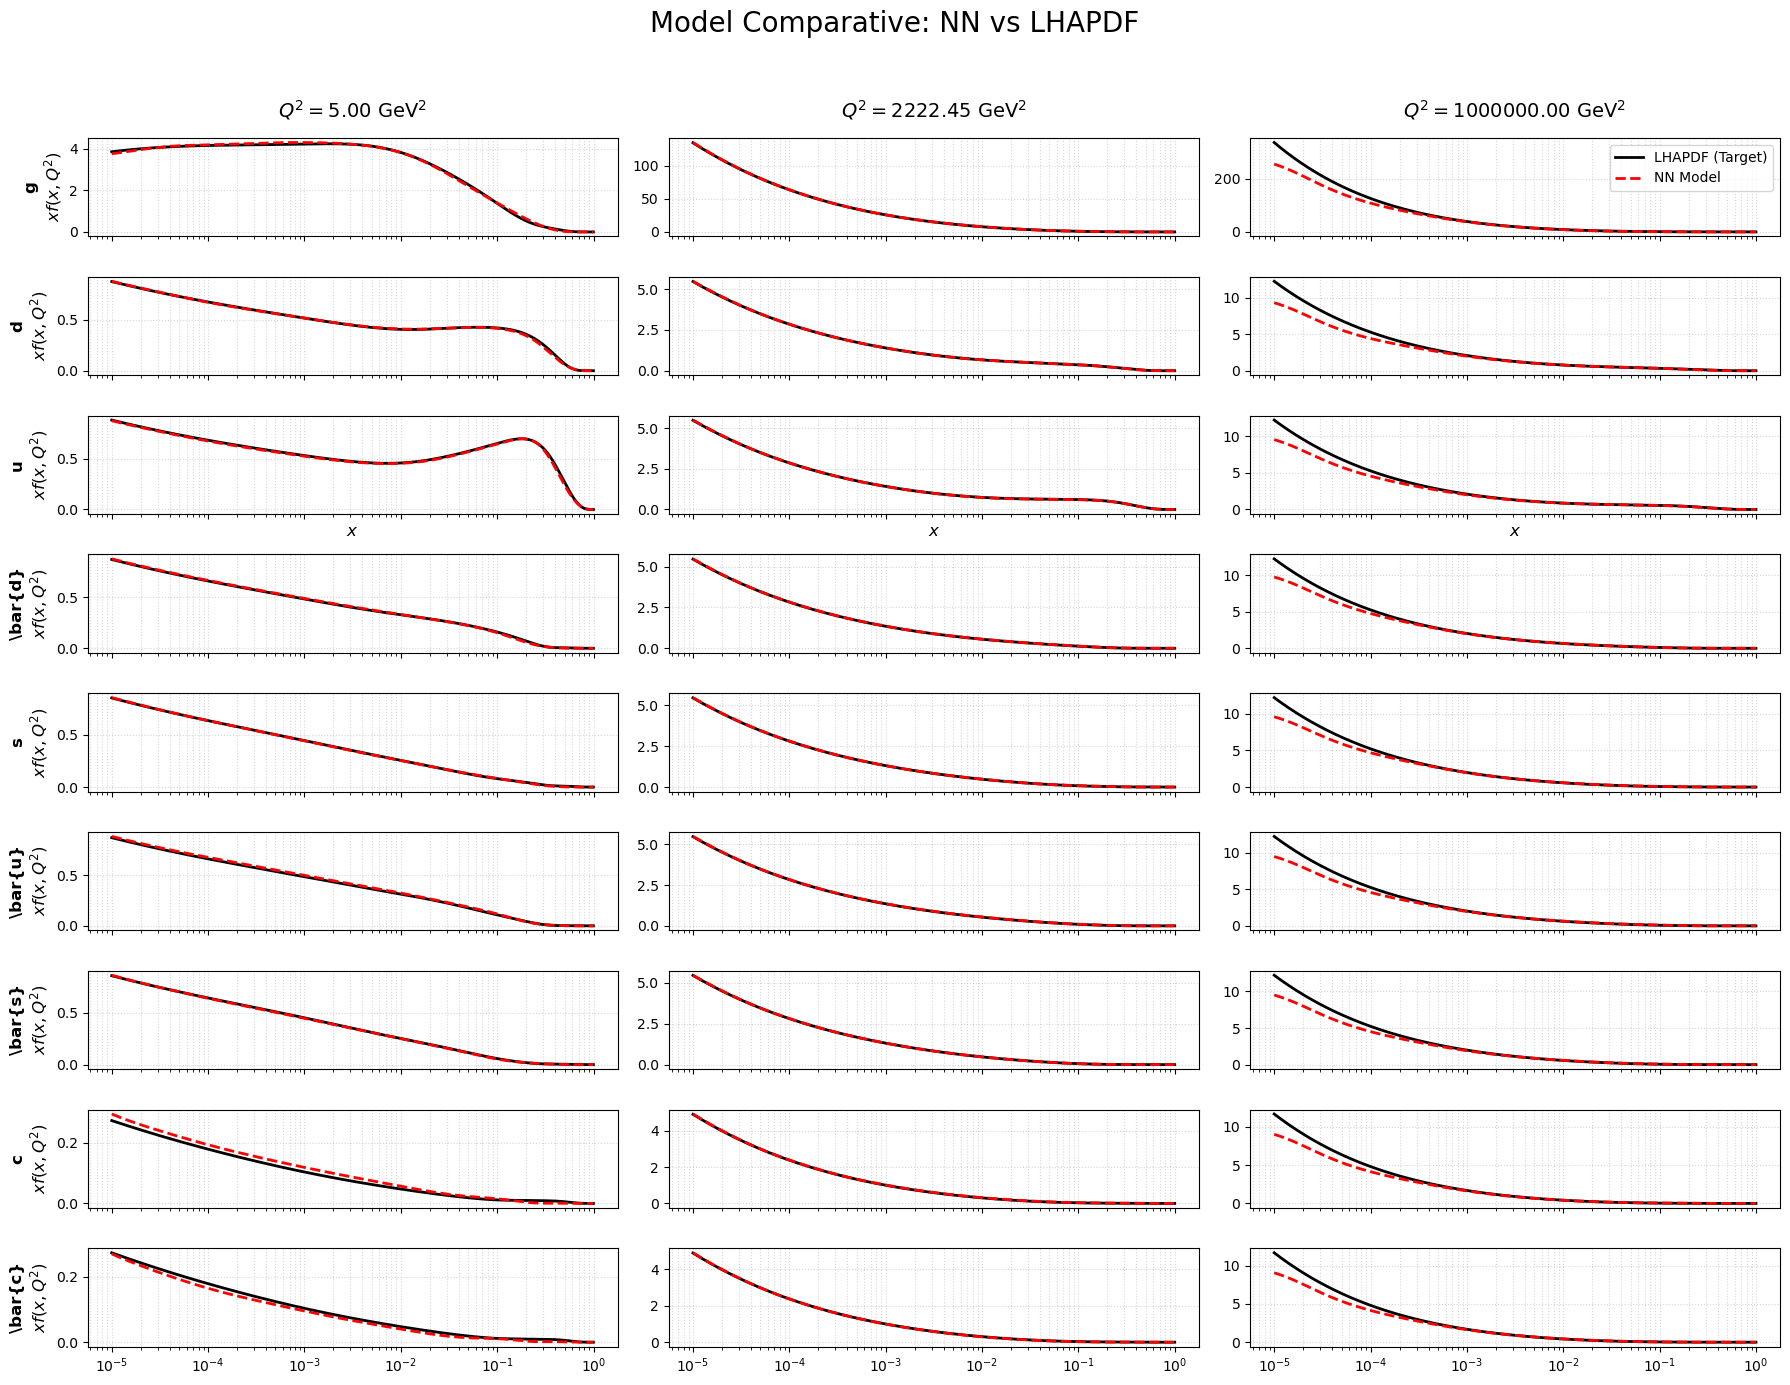

In [ ]:
# 1. Definig the PIDs to plot
pids_to_plot = [
    21,
    1,
    2,
    -1,
    3,
    -2,
    -3,
    4,
    -4,
]  # gluon, down, up, anti-down, strange, anti-strange, charm, anti-charm
pid_names = [
    pid_to_latex(p) for p in pids_to_plot
]  # Convert PIDs to LaTeX format for better plot labels

# 2. Select 3 representative Q^2 values for plotting (e.g., low, medium, high)
unique_q2_vals = np.unique(q2_inputs)
indices_q2 = np.linspace(0, len(unique_q2_vals) - 1, 3, dtype=int)
selected_q2 = unique_q2_vals[indices_q2]

# 3. Configure the subplots: 9 rows x 3 columns (9 flavors x 3 Q^2 values)
fig, axes = plt.subplots(9, 3, figsize=(18, 15), sharex=True)

for row, pid in enumerate(pids_to_plot):
    idx_in_basis = output_basis.index(pid)
    latex_name = pid_to_latex(pid)

    for col, q2_val in enumerate(selected_q2):
        ax = axes[row, col]

        # Mask to select the data for the current PID and Q^2 value
        q2_mask = q2_inputs == q2_val

        # Filter the data for the current PID and Q^2 value
        x_plot = x_inputs[q2_mask]
        real_plot = output_data[q2_mask, idx_in_basis]
        pred_plot = predictions[q2_mask, idx_in_basis]

        sort_idx = np.argsort(x_plot)
        x_plot = x_plot[sort_idx]
        real_plot = real_plot[sort_idx]
        pred_plot = pred_plot[sort_idx]

        # Graph the real and predicted PDFs
        ax.plot(x_plot, real_plot, "k-", lw=2, label="LHAPDF (Target)")
        ax.plot(x_plot, pred_plot, "r--", lw=2, label="NN Model")

        # Format the plot
        ax.set_xscale("log")
        if row == 0:
            ax.set_title(f"$Q^2 = {q2_val:.2f}$ GeV$^2$", fontsize=14, pad=15)
        if col == 0:
            ax.set_ylabel(
                f"{pid_names[row]}\n$x f(x, Q^2)$", fontsize=12, fontweight="bold"
            )
        if row == 2:
            ax.set_xlabel("$x$", fontsize=12)

        ax.grid(True, which="both", ls=":", alpha=0.5)
        if row == 0 and col == 2:
            ax.legend()

plt.suptitle("Model Comparative: NN vs LHAPDF", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


A more general way to view PDFs is to represent them using valence quarks ($q - \bar{q}$) and the quark sea produced by the creation of quark-antiquark pairs. The PDF will be represented for a value close to $Q = 91 GeV$ which corresponds to the mass of the Z boson.

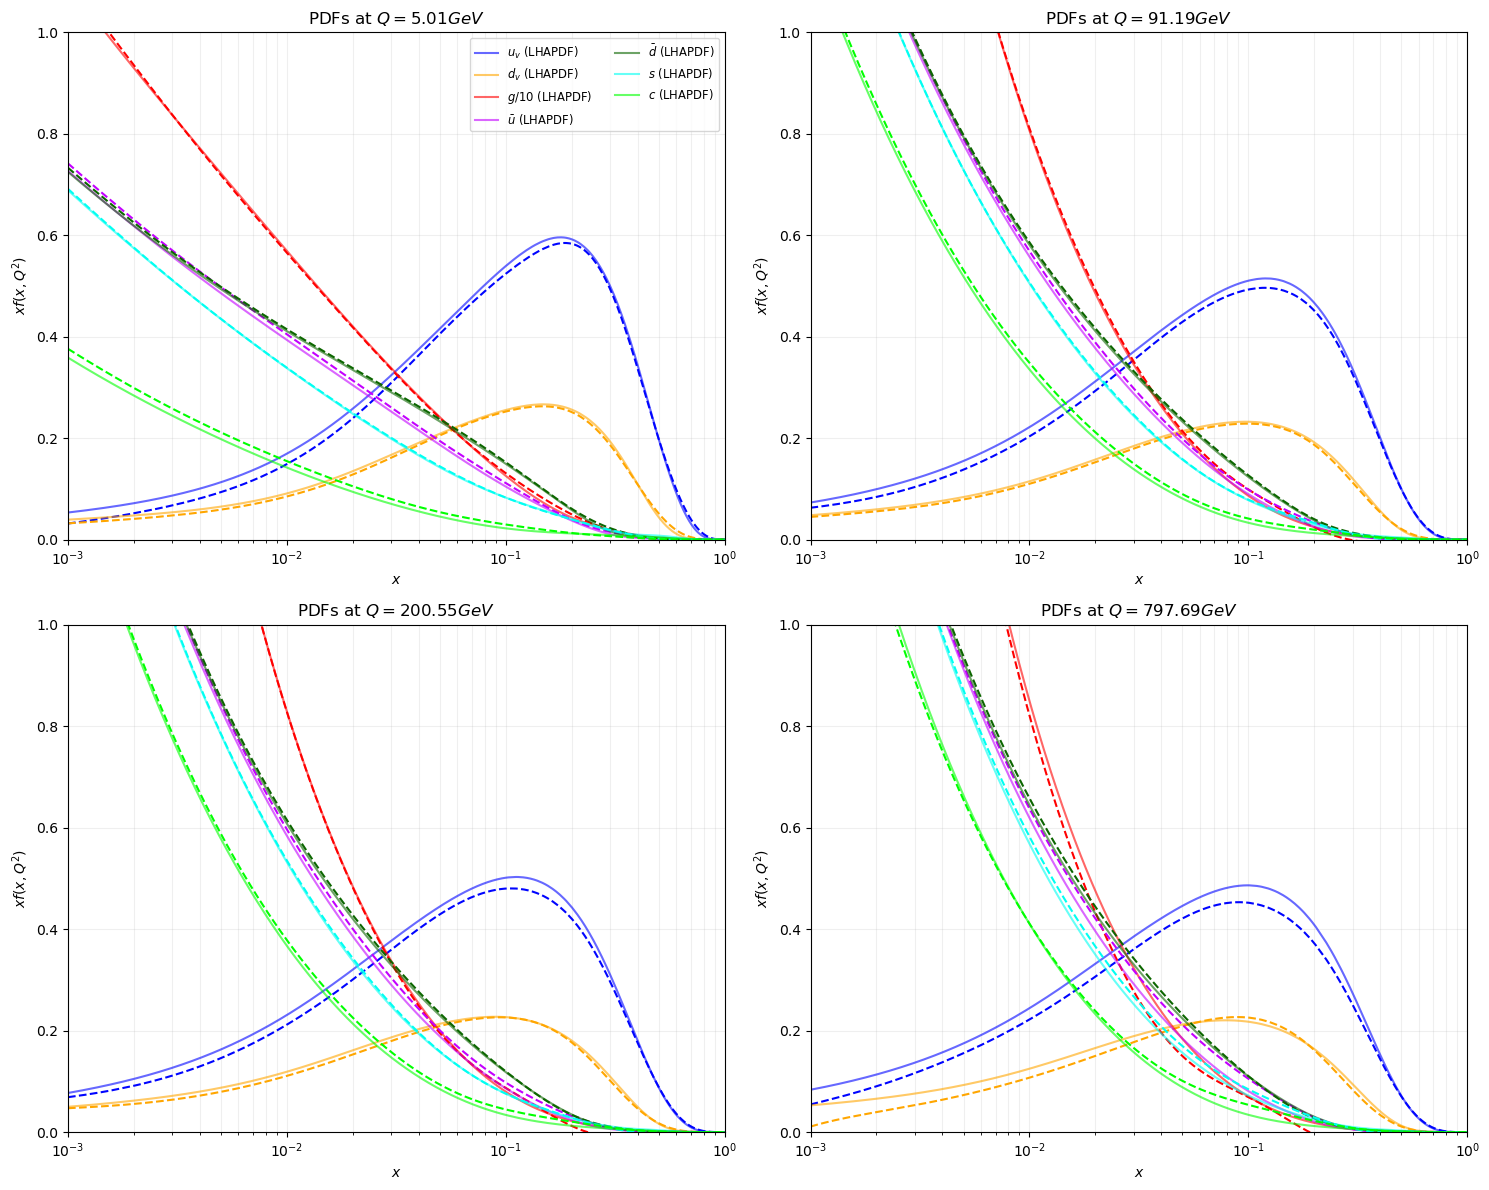

In [ ]:
# Additional plots for specific combinations of flavors (valence, gluon/10, etc.) at different Q^2 values
q_values = [5, 91, 200, 800]
q2_values_to_plot = [q**2 for q in q_values]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Define the indices for the flavors in the output data based on the output_basis
idx = {"u_bar": 2, "d_bar": 3, "g": 4, "d": 5, "u": 6, "s": 7, "c": 8}

for i, q2_target in enumerate(q2_values_to_plot):
    ax = axes[i]

    # Find the closest Q2 value in the dataset to the target Q2 for plotting
    available_q2 = np.unique(q2_inputs)
    closest_q2 = available_q2[np.abs(available_q2 - q2_target).argmin()]
    closest_q = np.sqrt(closest_q2)

    # Filter the data for this Q2
    mask_q2 = q2_inputs == closest_q2
    x_plot = x_inputs[mask_q2]
    y_true = output_data[mask_q2]
    y_pred = predictions[mask_q2]

    # Sort by x for continuous lines
    sort_idx = np.argsort(x_plot)
    x_s = x_plot[sort_idx]
    y_t_s = y_true[sort_idx]
    y_p_s = y_pred[sort_idx]

    # --- Calculate the specific combinations of flavors to plot ---
    # Val: u_v = u - u_bar | d_v = d - d_bar
    uv_t, uv_p = (
        y_t_s[:, idx["u"]] - y_t_s[:, idx["u_bar"]],
        y_p_s[:, idx["u"]] - y_p_s[:, idx["u_bar"]],
    )
    dv_t, dv_p = (
        y_t_s[:, idx["d"]] - y_t_s[:, idx["d_bar"]],
        y_p_s[:, idx["d"]] - y_p_s[:, idx["d_bar"]],
    )

    # Gluon / 10
    g10_t, g10_p = y_t_s[:, idx["g"]] / 10, y_p_s[:, idx["g"]] / 10

    # Others:
    ub_t, ub_p = y_t_s[:, idx["u_bar"]], y_p_s[:, idx["u_bar"]]
    db_t, db_p = y_t_s[:, idx["d_bar"]], y_p_s[:, idx["d_bar"]]
    s_t, s_p = y_t_s[:, idx["s"]], y_p_s[:, idx["s"]]
    c_t, c_p = y_t_s[:, idx["c"]], y_p_s[:, idx["c"]]

    # --- Plotting ---
    flavors = [
        (uv_t, uv_p, r"$u_v$", "#0004ff"),
        (dv_t, dv_p, r"$d_v$", "#ffa600"),
        (g10_t, g10_p, r"$g/10$", "#ff0000"),
        (ub_t, ub_p, r"$\bar{u}$", "#c300ff"),
        (db_t, db_p, r"$\bar{d}$", "#0C6600"),
        (s_t, s_p, r"$s$", "#00fff2"),
        (c_t, c_p, r"$c$", "#00ff00"),
    ]

    for true_val, pred_val, label, color in flavors:
        ax.plot(
            x_s,
            true_val,
            label=f"{label} (LHAPDF)",
            color=color,
            linestyle="-",
            alpha=0.6,
        )
        ax.plot(x_s, pred_val, color=color, linestyle="--", linewidth=1.5)

    ax.set_xscale("log")
    ax.set_xlim([1e-3, 1])
    ax.set_ylim([0, 1])
    ax.set_title(rf"PDFs at $Q = {closest_q:.2f} GeV$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$xf(x, Q^2)$")
    ax.grid(True, which="both", ls="-", alpha=0.2)
    if i == 0:
        ax.legend(loc="best", fontsize="small", ncol=2)

plt.tight_layout()
plt.show()